In [1]:
from Functional_Fusion.dataset import DataSetLanguage
import os
import Functional_Fusion.atlas_map as am
import nitools as nt
import matplotlib.pyplot as plt
from nilearn import plotting

In [2]:
base_dir = '/cifs/diedrichsen/data/FunctionalFusion'
if not os.path.exists(base_dir):
    base_dir = 'Y:/data/FunctionalFusion'

space = 'fs32k'

space = 'fs32k'
atlas,_= am.get_atlas(atlas_str=space)


In [9]:
MDTB_dataset = DataSetLanguage(f'{base_dir}/Language')
sub_list = ['sub-07']
data_mdtb_s1,info_mdtb_1  =MDTB_dataset.get_data(space=space,ses_id='ses-sencoding_category_duration',type='CondAll',subj=sub_list)

In [13]:
info_mdtb_1

,reg_id,n_rep,Unnamed: 0,taskName,task,inst,instOrder,time,sess,names
0,1,20.0,286,simple,1,0,0,1.7081,1,simple
1,2,20.0,287,simple_Speed,2,0,0,1.7081,1,simple_Speed
2,3,20.0,288,bigram,3,0,0,1.7081,1,bigram
3,4,20.0,289,wordlist,4,0,0,1.7081,1,wordlist
4,5,20.0,290,ambiguity_immed,5,0,0,1.7081,1,ambiguity_immed
5,6,20.0,291,ambiguity_delay,6,0,0,1.7081,1,ambiguity_delay
6,7,20.0,292,HE,7,0,0,1.7081,1,HE
7,8,20.0,293,LE,8,0,0,1.7081,1,LE
8,9,20.0,294,MSM,9,0,0,1.7081,1,MSM
9,10,20.0,295,MSE,10,0,0,1.7081,1,MSE


In [17]:
cort_dir = 'Y:/data/Atlas_templates/fs_LR_32'
  # Load surface files for left and right hemispheres
surfs = [f"{base_dir}/Atlases/tpl-fs32k/tpl-fs32k_hemi-{h}_inflated.surf.gii" for h in ['L', 'R']]

def plot_cortex(data, threshold=0.0, cmap='binary', figsize=(12, 6),title = 'figure'):  

    # Convert data to CIFTI format
    cifti = atlas.data_to_cifti(data)
    
    # Extract data for the cortical surfaces
    all_img = nt.surf_from_cifti(cifti)
    
    # Create the plot
    fig, axes = plt.subplots(1, 2, subplot_kw={'projection': '3d'}, figsize=figsize)
    for h, hemi in enumerate(['left', 'right']):
        plotting.plot_surf_stat_map(
            surfs[h], all_img[h], hemi=hemi,
            colorbar=False,
            cmap=cmap,
            axes=axes[h],
            threshold=threshold,
            title=f'{title} {hemi}'
        )
    
    return fig

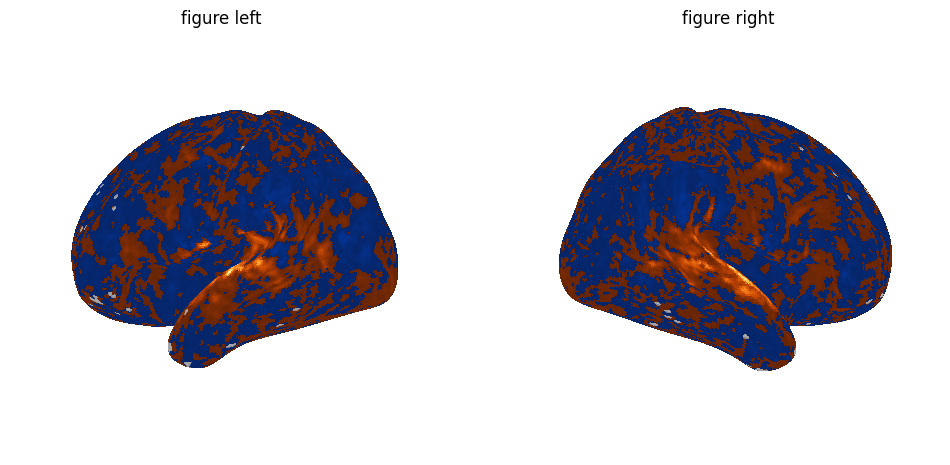

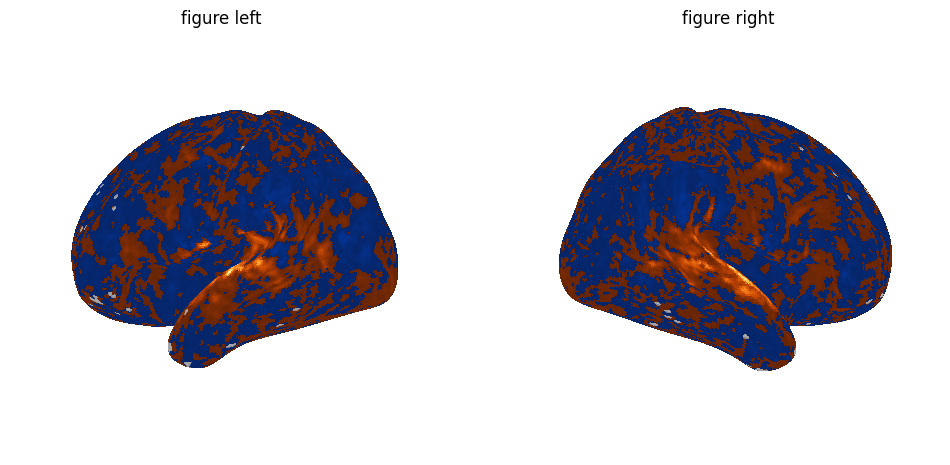

In [18]:
data = data_mdtb_s1[0][0].reshape(1,-1)
plot_cortex(data, threshold=0.0, cmap='cyan_orange', figsize=(12, 6),title = 'figure')

In [64]:
import numpy as np
# avg data
data_mdtb_s1_avg = data_mdtb_s1.mean(axis=0)
contrast = data_mdtb_s1_avg[16] - data_mdtb_s1_avg[17]
contrast_reshaped = contrast.reshape(1, contrast.shape[0])

# anything above certain percentile is 1 else 0
threshold = 0.02

#threhsold so everything above 90th percentile is 1 else 0
contrast_reshaped = np.where(contrast_reshaped > threshold, 1, 0)


In [65]:
np.sum(contrast_reshaped)

19873

In [66]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import ListedColormap

colors = ['blue', 'red']
blue_red_cmap = ListedColormap(colors)



ValueError: The bg_map does not have the same number of vertices as the mesh.

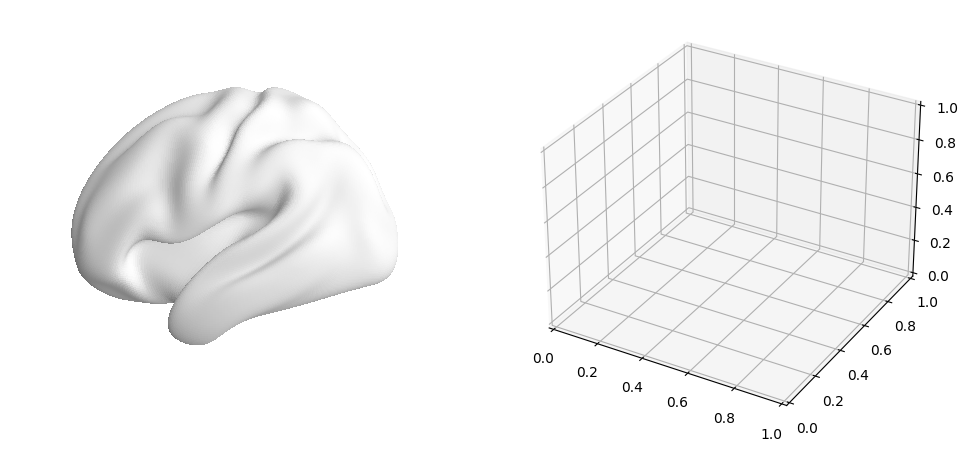

In [70]:
plot_cortex(contrast_reshaped, threshold=0.03, cmap='binary')
plt.show()

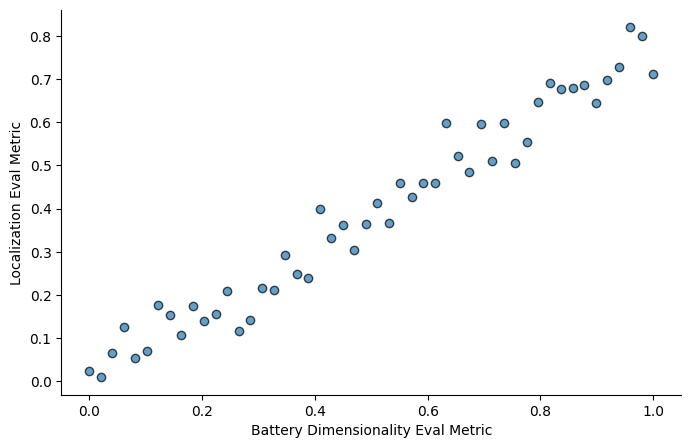

In [74]:
import numpy as np
import matplotlib.pyplot as plt

# Generate data
np.random.seed(42)  # For reproducibility
battery_dimensionality = np.linspace(0, 1, 50)  # Battery Dimensionality Eval Metric ranging from 0 to 1
localization_metric = 0.8 * battery_dimensionality + np.random.normal(0, 0.05, size=50)  # Slightly correlated with some noise

# Create scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(battery_dimensionality, localization_metric, alpha=0.7, edgecolors='k')
plt.xlabel('Battery Dimensionality Eval Metric')
plt.ylabel('Localization Eval Metric')

#remove the top and right spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Display the plot
plt.show()
